Libraries imported successfully!

Training Data:
[[90 85 90 82]
 [85 78 80 75]
 [75 70 72 68]
 [60 55 58 52]
 [55 48 50 45]
 [95 92 94 90]
 [65 60 62 58]
 [80 75 78 72]]

Training Labels:
[1 1 1 0 0 1 0 1]

Test Data:
[[92 88 90 85]
 [58 50 52 48]
 [82 76 80 74]
 [62 57 55 50]]

Standardized Training Data:
[[ 1.06  1.03  1.17  1.  ]
 [ 0.69  0.54  0.48  0.51]
 [-0.05 -0.03 -0.07  0.02]
 [-1.15 -1.09 -1.04 -1.1 ]
 [-1.52 -1.58 -1.59 -1.59]
 [ 1.43  1.53  1.45  1.56]
 [-0.78 -0.73 -0.76 -0.68]
 [ 0.32  0.33  0.35  0.3 ]]

MLP Model Created Successfully!
MLP Model Training Completed!

PREDICTION RESULTS
Student 1 -> Class = 1 -> PASS
Student 2 -> Class = 0 -> FAIL
Student 3 -> Class = 1 -> PASS
Student 4 -> Class = 0 -> FAIL

PREDICTION PROBABILITIES
Student 1: Fail = 0.36% | Pass = 99.64%
Student 2: Fail = 99.80% | Pass = 0.20%
Student 3: Fail = 3.36% | Pass = 96.64%
Student 4: Fail = 99.32% | Pass = 0.68%

MODEL EVALUATION
Training Accuracy: 100.00%

Classification Report:
             

<Figure size 600x500 with 0 Axes>

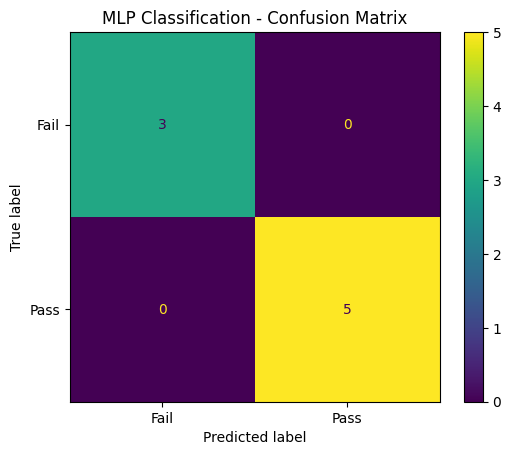

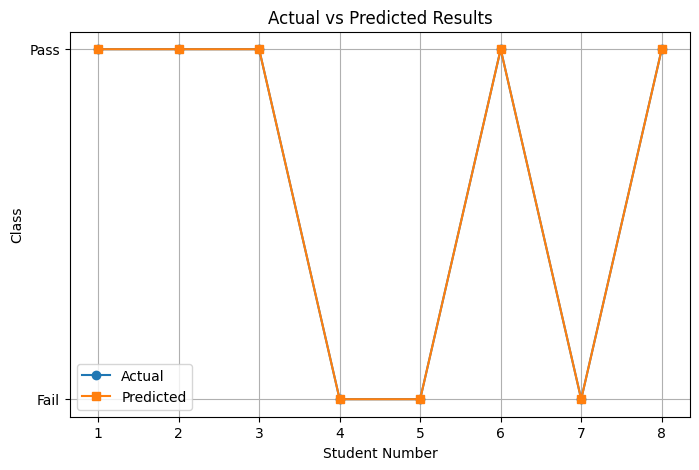

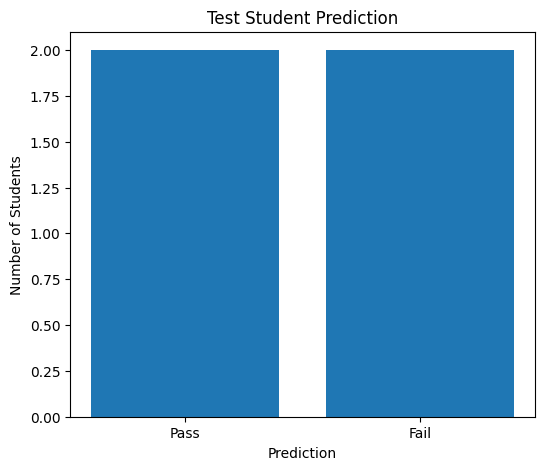


FINAL RESULT TABLE


,Student,Attendance,Internal Marks,Assignment Marks,Previous Semester,Predicted Class,Result
0,1,92,88,90,85,1,Pass
1,2,58,50,52,48,0,Fail
2,3,82,76,80,74,1,Pass
3,4,62,57,55,50,0,Fail



NEW STUDENT PREDICTION
Attendance       : 88
Internal Marks   : 82
Assignment Marks : 85
Previous Semester: 80
Predicted Result : PASS
Fail Probability : 1.00%
Pass Probability : 99.00%

PROGRAM EXECUTION COMPLETED


In [1]:
# ============================================================
# MACHINE LEARNING - UNIT 1
# MLP CLASSIFICATION
# Student Pass / Fail Prediction
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")


# -----------------------------
# 2. CREATE TRAINING DATA
# -----------------------------

# Features:
# Attendance
# Internal Marks
# Assignment Marks
# Previous Semester Marks

X_train = np.array([
    [90, 85, 90, 82],
    [85, 78, 80, 75],
    [75, 70, 72, 68],
    [60, 55, 58, 52],
    [55, 48, 50, 45],
    [95, 92, 94, 90],
    [65, 60, 62, 58],
    [80, 75, 78, 72]
])

# Class labels:
# 1 = Pass
# 0 = Fail

y_train = np.array([
    1,
    1,
    1,
    0,
    0,
    1,
    0,
    1
])

print("\nTraining Data:")
print(X_train)

print("\nTraining Labels:")
print(y_train)


# -----------------------------
# 3. CREATE TEST DATA
# -----------------------------

X_test = np.array([
    [92, 88, 90, 85],
    [58, 50, 52, 48],
    [82, 76, 80, 74],
    [62, 57, 55, 50]
])

print("\nTest Data:")
print(X_test)


# -----------------------------
# 4. STANDARDIZATION
# -----------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nStandardized Training Data:")
print(np.round(X_train_scaled, 2))


# -----------------------------
# 5. CREATE MLP MODEL
# -----------------------------

model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

print("\nMLP Model Created Successfully!")


# -----------------------------
# 6. TRAIN THE MODEL
# -----------------------------

model.fit(X_train_scaled, y_train)

print("MLP Model Training Completed!")


# -----------------------------
# 7. PREDICT TEST STUDENTS
# -----------------------------

y_pred = model.predict(X_test_scaled)

print("\n===================================")
print("PREDICTION RESULTS")
print("===================================")

for i, prediction in enumerate(y_pred):
    if prediction == 1:
        result = "PASS"
    else:
        result = "FAIL"

    print(
        "Student", i + 1,
        "-> Class =", prediction,
        "->", result
    )


# -----------------------------
# 8. PREDICTION PROBABILITY
# -----------------------------

probabilities = model.predict_proba(X_test_scaled)

print("\n===================================")
print("PREDICTION PROBABILITIES")
print("===================================")

for i, prob in enumerate(probabilities):

    print(
        f"Student {i+1}: "
        f"Fail = {prob[0]*100:.2f}% | "
        f"Pass = {prob[1]*100:.2f}%"
    )


# -----------------------------
# 9. TRAINING DATA PREDICTION
# -----------------------------

train_prediction = model.predict(X_train_scaled)

accuracy = accuracy_score(
    y_train,
    train_prediction
)

print("\n===================================")
print("MODEL EVALUATION")
print("===================================")

print(
    f"Training Accuracy: {accuracy * 100:.2f}%"
)


# -----------------------------
# 10. CLASSIFICATION REPORT
# -----------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_train,
        train_prediction,
        target_names=["Fail", "Pass"]
    )
)


# -----------------------------
# 11. CONFUSION MATRIX
# -----------------------------

cm = confusion_matrix(
    y_train,
    train_prediction
)

print("\nConfusion Matrix:")
print(cm)


# -----------------------------
# 12. CONFUSION MATRIX GRAPH
# -----------------------------

plt.figure(figsize=(6, 5))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

display_cm.plot()

plt.title("MLP Classification - Confusion Matrix")
plt.show()


# -----------------------------
# 13. ACTUAL VS PREDICTED GRAPH
# -----------------------------

plt.figure(figsize=(8, 5))

students = np.arange(1, len(y_train) + 1)

plt.plot(
    students,
    y_train,
    marker='o',
    label='Actual'
)

plt.plot(
    students,
    train_prediction,
    marker='s',
    label='Predicted'
)

plt.xlabel("Student Number")
plt.ylabel("Class")
plt.title("Actual vs Predicted Results")

plt.yticks(
    [0, 1],
    ["Fail", "Pass"]
)

plt.legend()
plt.grid(True)

plt.show()


# -----------------------------
# 14. TEST STUDENT RESULT GRAPH
# -----------------------------

test_results = [
    "Pass" if x == 1 else "Fail"
    for x in y_pred
]

pass_count = test_results.count("Pass")
fail_count = test_results.count("Fail")

plt.figure(figsize=(6, 5))

plt.bar(
    ["Pass", "Fail"],
    [pass_count, fail_count]
)

plt.xlabel("Prediction")
plt.ylabel("Number of Students")
plt.title("Test Student Prediction")

plt.show()


# -----------------------------
# 15. FINAL OUTPUT TABLE
# -----------------------------

result_table = pd.DataFrame({
    "Student": [1, 2, 3, 4],
    "Attendance": X_test[:, 0],
    "Internal Marks": X_test[:, 1],
    "Assignment Marks": X_test[:, 2],
    "Previous Semester": X_test[:, 3],
    "Predicted Class": y_pred,
    "Result": test_results
})

print("\n===================================")
print("FINAL RESULT TABLE")
print("===================================")

display(result_table)


# -----------------------------
# 16. PREDICT A NEW STUDENT
# -----------------------------

new_student = np.array([
    [88, 82, 85, 80]
])

new_student_scaled = scaler.transform(
    new_student
)

new_prediction = model.predict(
    new_student_scaled
)[0]

new_probability = model.predict_proba(
    new_student_scaled
)[0]

print("\n===================================")
print("NEW STUDENT PREDICTION")
print("===================================")

print("Attendance       :", new_student[0][0])
print("Internal Marks   :", new_student[0][1])
print("Assignment Marks :", new_student[0][2])
print("Previous Semester:", new_student[0][3])

if new_prediction == 1:
    print("Predicted Result : PASS")
else:
    print("Predicted Result : FAIL")

print(
    f"Fail Probability : {new_probability[0]*100:.2f}%"
)

print(
    f"Pass Probability : {new_probability[1]*100:.2f}%"
)


# -----------------------------
# 17. FINAL MESSAGE
# -----------------------------

print("\n===================================")
print("PROGRAM EXECUTION COMPLETED")
print("===================================")